# Stock analysis

## 1. Introduction

### Data overview

### Variables

### Data limitations

### Goal of the analysis

### Key findings

### Models used

### Where to improve this project in the future?

## 2. Data overview

### 2.1 Imports

In [ ]:
import warnings

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd


from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import (
    RandomForestRegressor, 
    GradientBoostingRegressor, 
    VotingRegressor, 
    StackingRegressor
)
import lightgbm as lgb
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored

import joblib
from sklearn.metrics import mean_absolute_error

In [2]:
from functions import (
    split_time_series_data,
    create_master_dataset,
    prepare_feature_matrices,
    
    plot_stock_trends,
    plot_decomposition_grid,
    plot_ticker_performance_comparison,
    
    run_stationarity_tests,
    clean_and_verify_stationarity,
    plot_differencing_comparison,
    plot_acf_grid,
    plot_pacf_grid,
    
    create_master_dataset,
    prepare_feature_matrices, 

    plot_model_comparison, 
    plot_ticker_performance_comparison, 
    get_best_params_for_model, 

    clean_params, 
    evaluate_ensemble,

    plot_kaplan_meier,
    plot_ticker_survival_comparison,
    plot_rsf_predictions,
    
    prep_ranking_data,
    pairwise_accuracy
)

### 2.2 Data loading

Loading the data.

In [3]:
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "META"]

In [4]:
data = pd.read_csv("stocks_data.csv", header=[0, 1], index_col=0, parse_dates=True)

print(data['Close'].head())

Ticker          AAPL    AMZN      GOOGL  META       MSFT
Date                                                    
2010-01-04  6.406479  6.6950  15.555865   NaN  23.077381
2010-01-05  6.417556  6.7345  15.487363   NaN  23.084841
2010-01-06  6.315477  6.6125  15.096946   NaN  22.943167
2010-01-07  6.303802  6.5000  14.745495   NaN  22.704557
2010-01-08  6.345711  6.6760  14.942070   NaN  22.861145


### 2.3 Splitting the data

In [5]:
train_df_raw, val_df_raw, test_df_raw = split_time_series_data(data)

Total Rows: 4085
Train Size: 2859 (70.0%)
Val Size:   613 (15.0%)
Test Size:  613 (15.0%)


Since this data is time series, splits were done chronologically (first part of the data period - test data, the middle part of the data - validation data, the final part of the data - testing dataset). This is important because the model must not see the future (which can happen in a random split).

In this dataset there is 4085 days worth of data (16+ years).

## 3. Inspecting data

In [6]:
train_df_raw.isnull().sum()

Price   Ticker
Close   AAPL        0
        AMZN        0
        GOOGL       0
        META      599
        MSFT        0
High    AAPL        0
        AMZN        0
        GOOGL       0
        META      599
        MSFT        0
Low     AAPL        0
        AMZN        0
        GOOGL       0
        META      599
        MSFT        0
Open    AAPL        0
        AMZN        0
        GOOGL       0
        META      599
        MSFT        0
Volume  AAPL        0
        AMZN        0
        GOOGL       0
        META      599
        MSFT        0
dtype: int64

In [7]:
print(train_df_raw['High']['META'].head(600))

Date
2010-01-04         NaN
2010-01-05         NaN
2010-01-06         NaN
2010-01-07         NaN
2010-01-08         NaN
                ...   
2012-05-14         NaN
2012-05-15         NaN
2012-05-16         NaN
2012-05-17         NaN
2012-05-18    44.64961
Name: META, Length: 600, dtype: float64


I see that there are no missing values, except for the META stock. This stock data starts later than others (on 2012-05-18 comparing to the chosen start date of 2010-01-04 for other stocks).

## 4. Exploratory data analysis

Plotting High Stock Prices

Since the 'High'column is of continuous data type we will use line graph to visualize it.

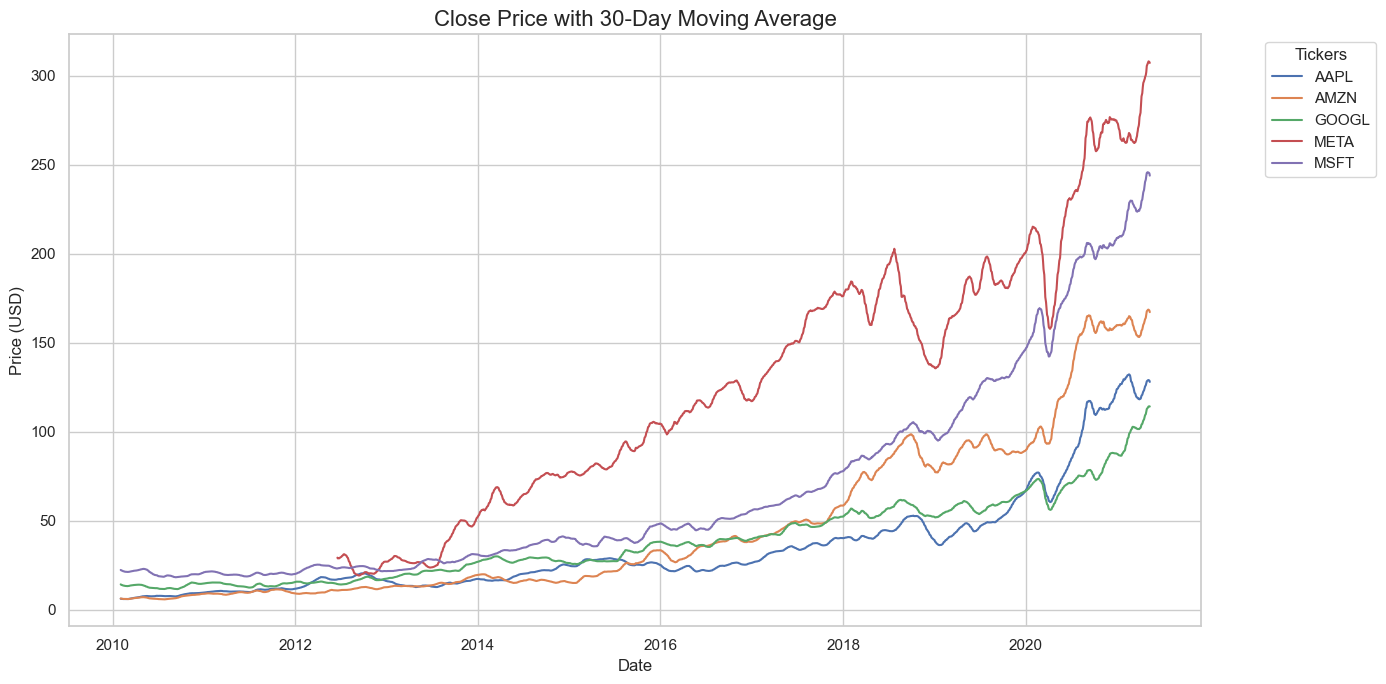

In [9]:
plot_stock_trends(train_df_raw, window=21, title='Stock Closing Prices with 30-Day Moving Average')

- All five stocks have an upward trajectory, which makes sense, because these companies are tech companies
- META - this stock had the fastest growth and highest prices
- MSFT - Microsoft stock was growing steadily, has the second highest price of all five stocks
- Amazon (AMZN) had similar price to the Google (GOOGL) stock at around 2017, but now is the third highest price
- Google stock had the forth highest price, but after 2020 and the start of the pandemic, the price is not growing as sharply
- From the 2016 Apple (AAPL) stock had the lowest price out of these five, but after 2020 it surpassed the Google stock price
- Up until 2018 stock prices are growing similarly except for the Meta stock, which was growing rapidly

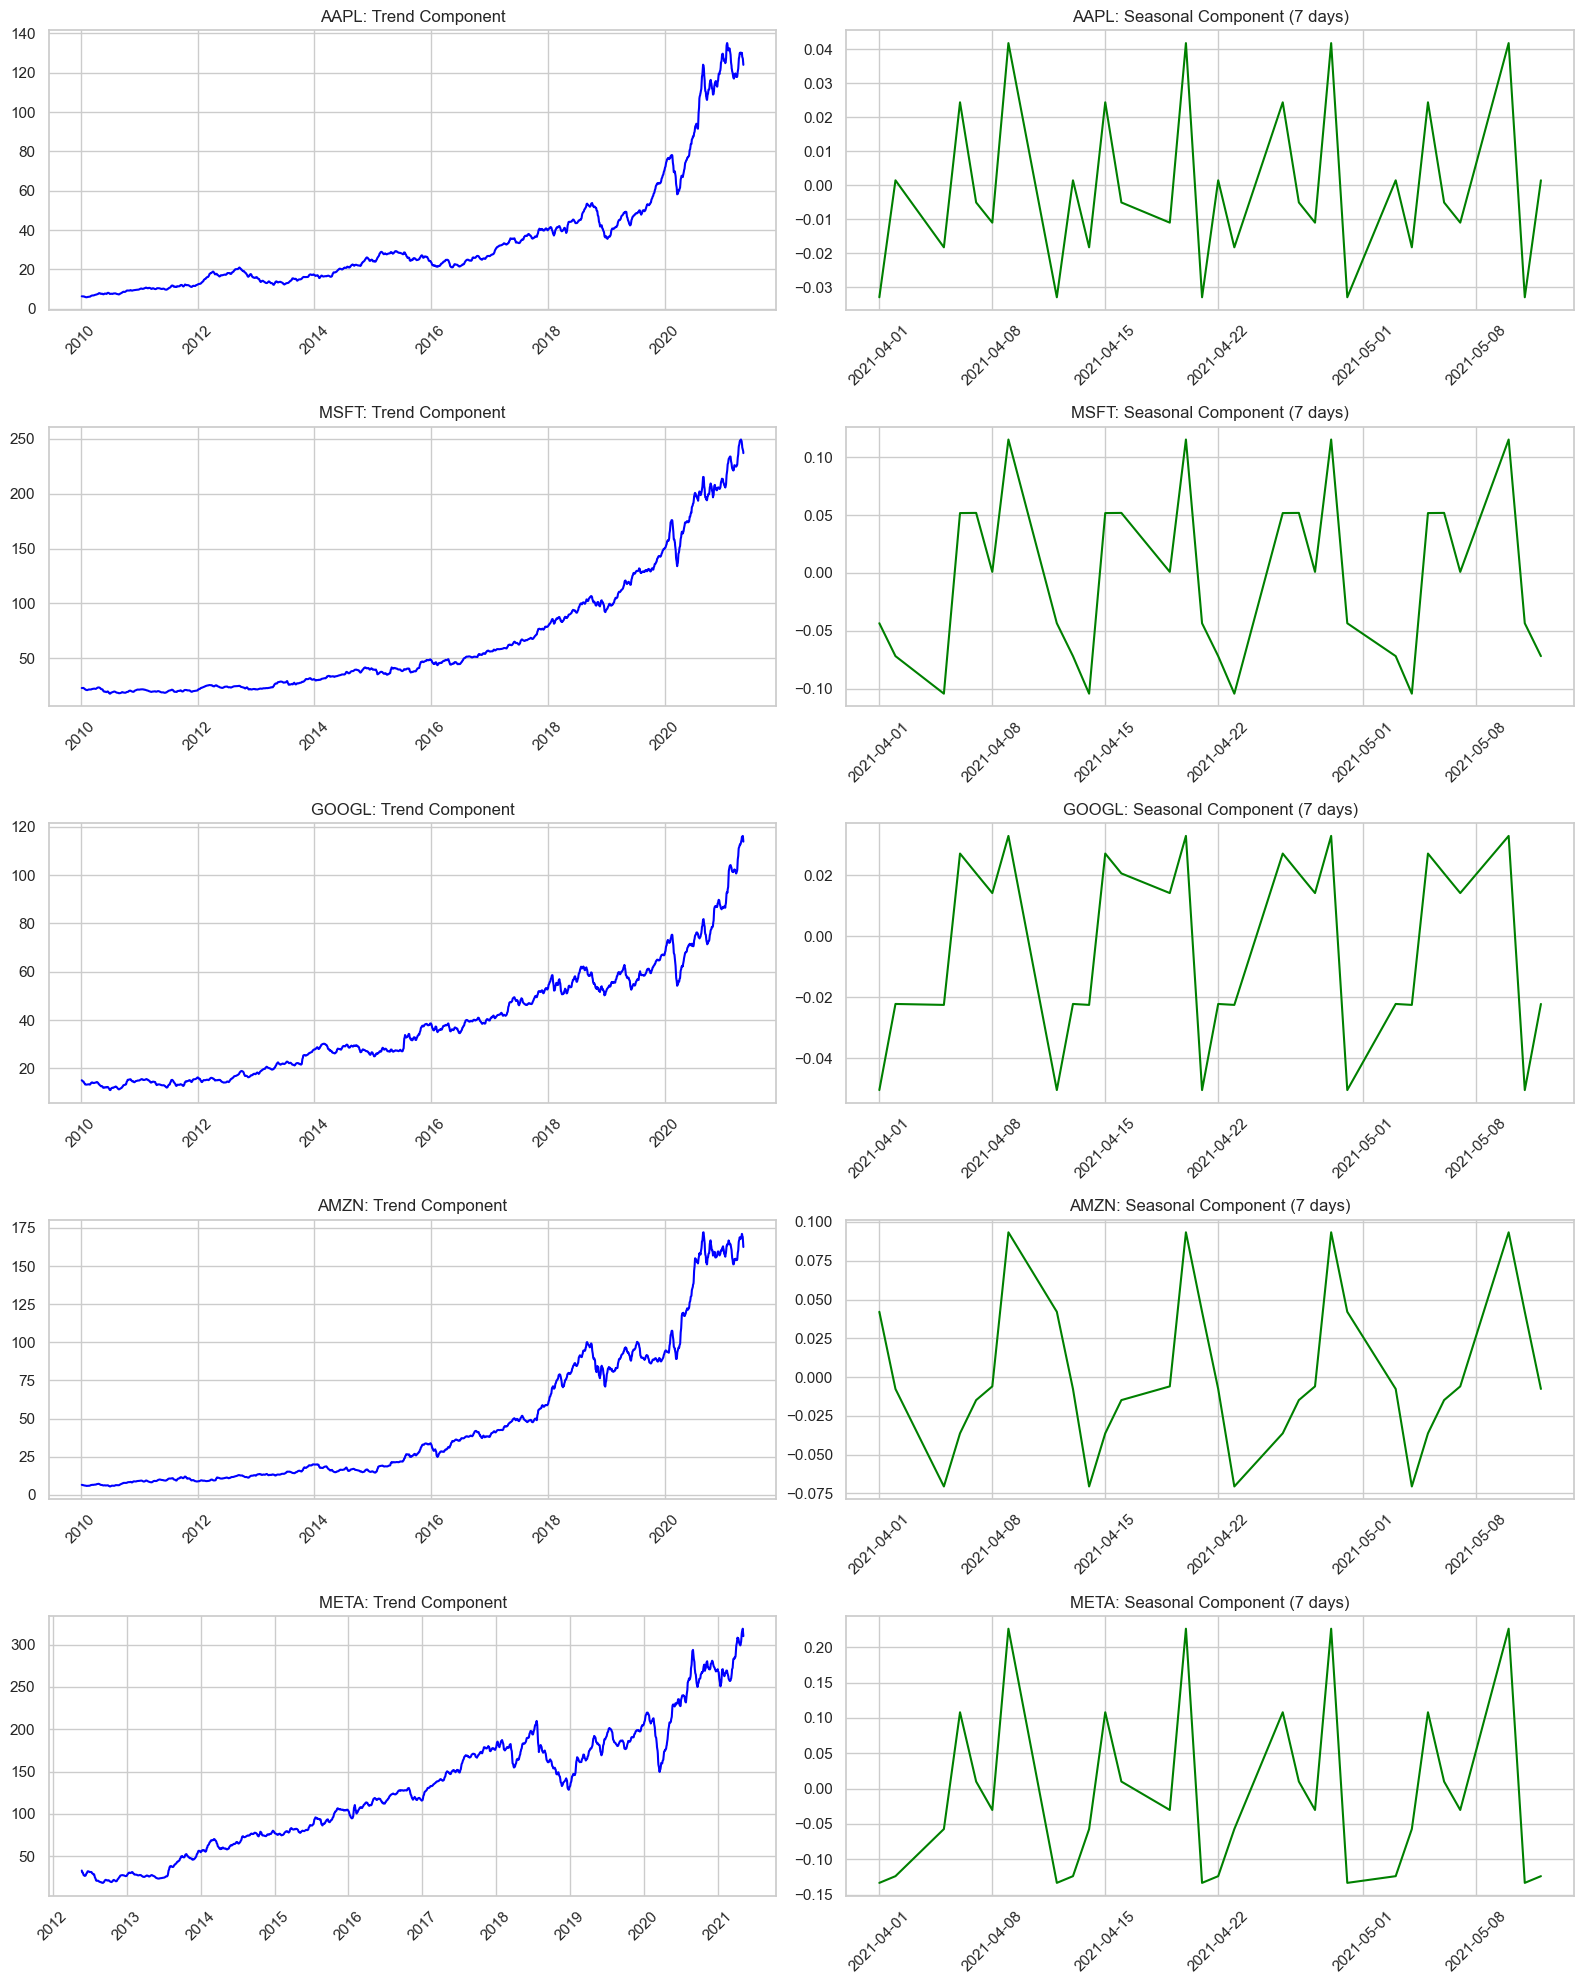

In [10]:
plot_decomposition_grid(train_df_raw, tickers)

- The trend of all stocks is upwards with a few dips, mostly around 2020.
- Stocks have no seasonality, the pattern is just a mathematical noise, since the scale is very small comparing to the scale in the trend line.

Detecting Seasonality with Autocorrelation

We will detect Seasonality using the autocorrelation function (ACF) plot. Peaks at regular intervals in the ACF plot suggest the presence of seasonality.

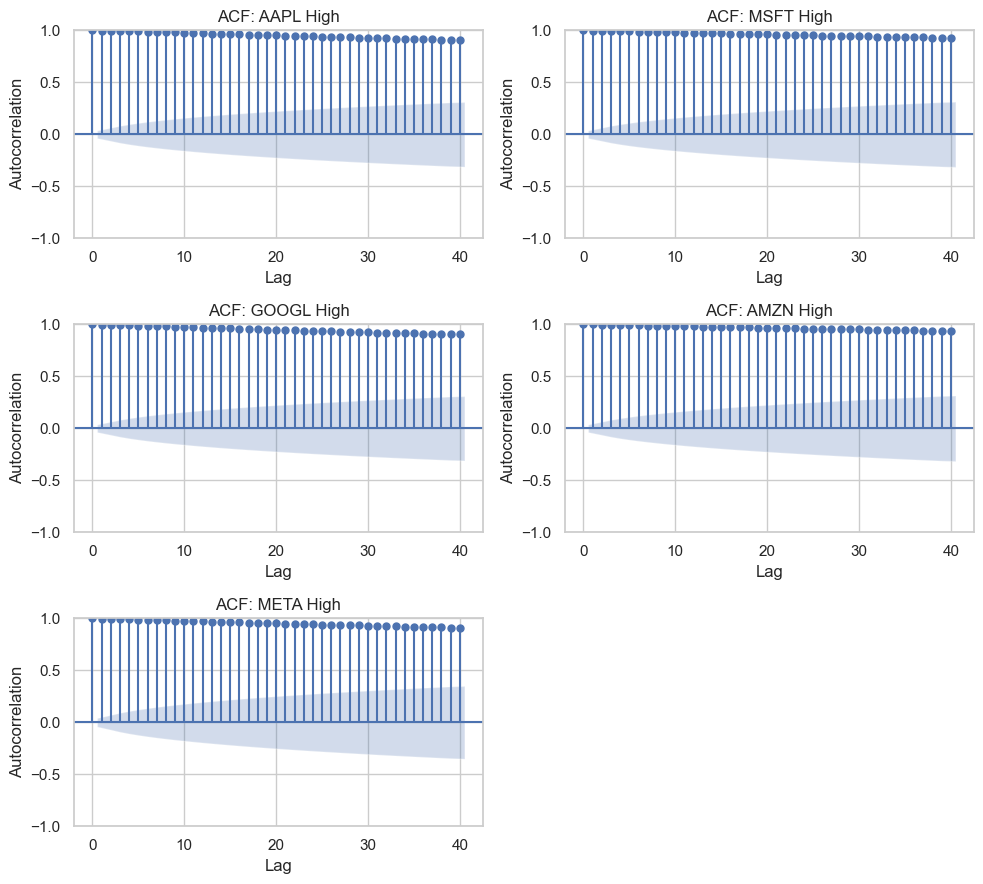

In [11]:
plot_acf_grid(train_df_raw, tickers, lags=40, column='High')

- The peaks are close to 1.0, this shows high autocorrelation
- The data is not stationary, it needs fixing before modelling
- We should not rely on seasonality for this raw stock data

Testing Stationarity with ADF test

We will perform the ADF test to test for stationarity.

In [12]:
run_stationarity_tests(train_df_raw, tickers)

ADF Test Results for AAPL High
ADF Statistic: 1.7154
p-value: 0.9982
Critical Values:
   1%: -3.4327
   5%: -2.8626
   10%: -2.5673

The series is Non-Stationary.

ADF Test Results for MSFT High
ADF Statistic: 5.1223
p-value: 1.0000
Critical Values:
   1%: -3.4327
   5%: -2.8626
   10%: -2.5673

The series is Non-Stationary.

ADF Test Results for GOOGL High
ADF Statistic: 2.4763
p-value: 0.9990
Critical Values:
   1%: -3.4327
   5%: -2.8626
   10%: -2.5673

The series is Non-Stationary.

ADF Test Results for AMZN High
ADF Statistic: 2.0124
p-value: 0.9987
Critical Values:
   1%: -3.4327
   5%: -2.8626
   10%: -2.5673

The series is Non-Stationary.

ADF Test Results for META High
ADF Statistic: 0.3459
p-value: 0.9794
Critical Values:
   1%: -3.4333
   5%: -2.8628
   10%: -2.5675

The series is Non-Stationary.



Based on the ADF Statistic we accept the null hypothesis, indicating that the data is not stationary according to the Augmented Dickey-Fuller test.
This suggests that differencing or other transformations may be needed to achieve stationarity before applying certain time series models.

Differencing to Achieve Stationarity

Differencing involves subtracting the previous observation from the current observation to remove trends or seasonality. 

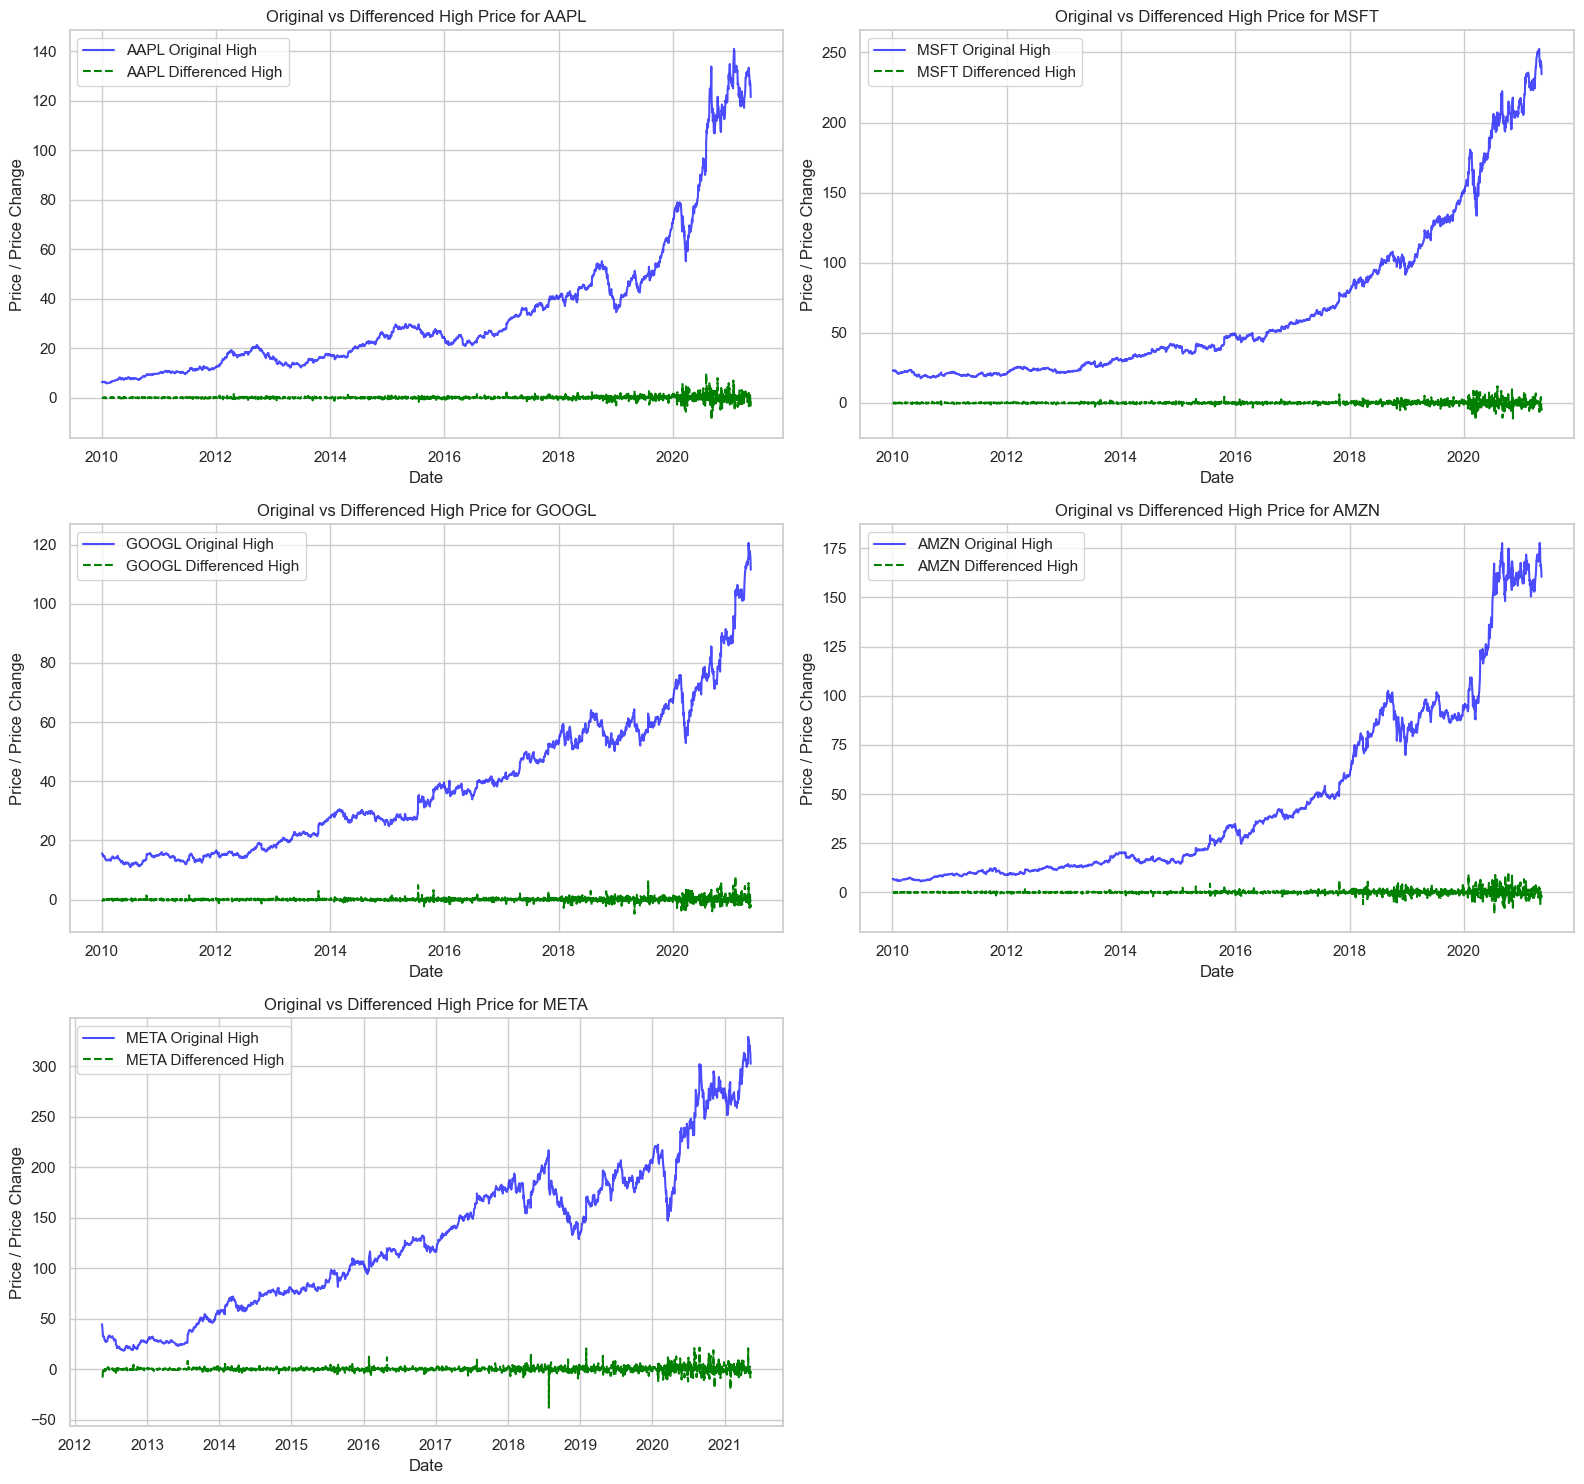

In [13]:
plot_differencing_comparison(train_df_raw, tickers)

- The blue line shows raw data (high price)
- Green line represents a differenced high (showing a difference from the previous day). This removes the trend from the data, the data is now around zero and it can be used for the modelling.

Original Data vs. Differenced Data

In [14]:
cleaned_train_dfs = clean_and_verify_stationarity(train_df_raw, tickers)

TICKER: AAPL
ADF Statistic: -10.4551
p-value: 0.0000
Result: Stationary (Ready for modeling)

TICKER: MSFT
ADF Statistic: -13.8919
p-value: 0.0000
Result: Stationary (Ready for modeling)

TICKER: GOOGL
ADF Statistic: -11.5973
p-value: 0.0000
Result: Stationary (Ready for modeling)

TICKER: AMZN
ADF Statistic: -11.5161
p-value: 0.0000
Result: Stationary (Ready for modeling)

TICKER: META
ADF Statistic: -9.7374
p-value: 0.0000
Result: Stationary (Ready for modeling)



- Based on the ADF Statistic we reject the null hypothesis, indicating that the data is stationary according to the Augmented Dickey-Fuller test. This suggests that it can be used for the time series models.
- The same transformation is performed on the validation and test datasets.

In [15]:
cleaned_val_dfs = clean_and_verify_stationarity(val_df_raw, tickers)

TICKER: AAPL
ADF Statistic: -22.9291
p-value: 0.0000
Result: Stationary (Ready for modeling)

TICKER: MSFT
ADF Statistic: -17.8403
p-value: 0.0000
Result: Stationary (Ready for modeling)

TICKER: GOOGL
ADF Statistic: -22.0507
p-value: 0.0000
Result: Stationary (Ready for modeling)

TICKER: AMZN
ADF Statistic: -22.2896
p-value: 0.0000
Result: Stationary (Ready for modeling)

TICKER: META
ADF Statistic: -22.8621
p-value: 0.0000
Result: Stationary (Ready for modeling)



In [16]:
cleaned_test_dfs = clean_and_verify_stationarity(test_df_raw, tickers)

TICKER: AAPL
ADF Statistic: -12.6898
p-value: 0.0000
Result: Stationary (Ready for modeling)

TICKER: MSFT
ADF Statistic: -24.5416
p-value: 0.0000
Result: Stationary (Ready for modeling)

TICKER: GOOGL
ADF Statistic: -23.5495
p-value: 0.0000
Result: Stationary (Ready for modeling)

TICKER: AMZN
ADF Statistic: -17.9796
p-value: 0.0000
Result: Stationary (Ready for modeling)

TICKER: META
ADF Statistic: -14.0406
p-value: 0.0000
Result: Stationary (Ready for modeling)



Plotting PACF graphs to decide the number of lags

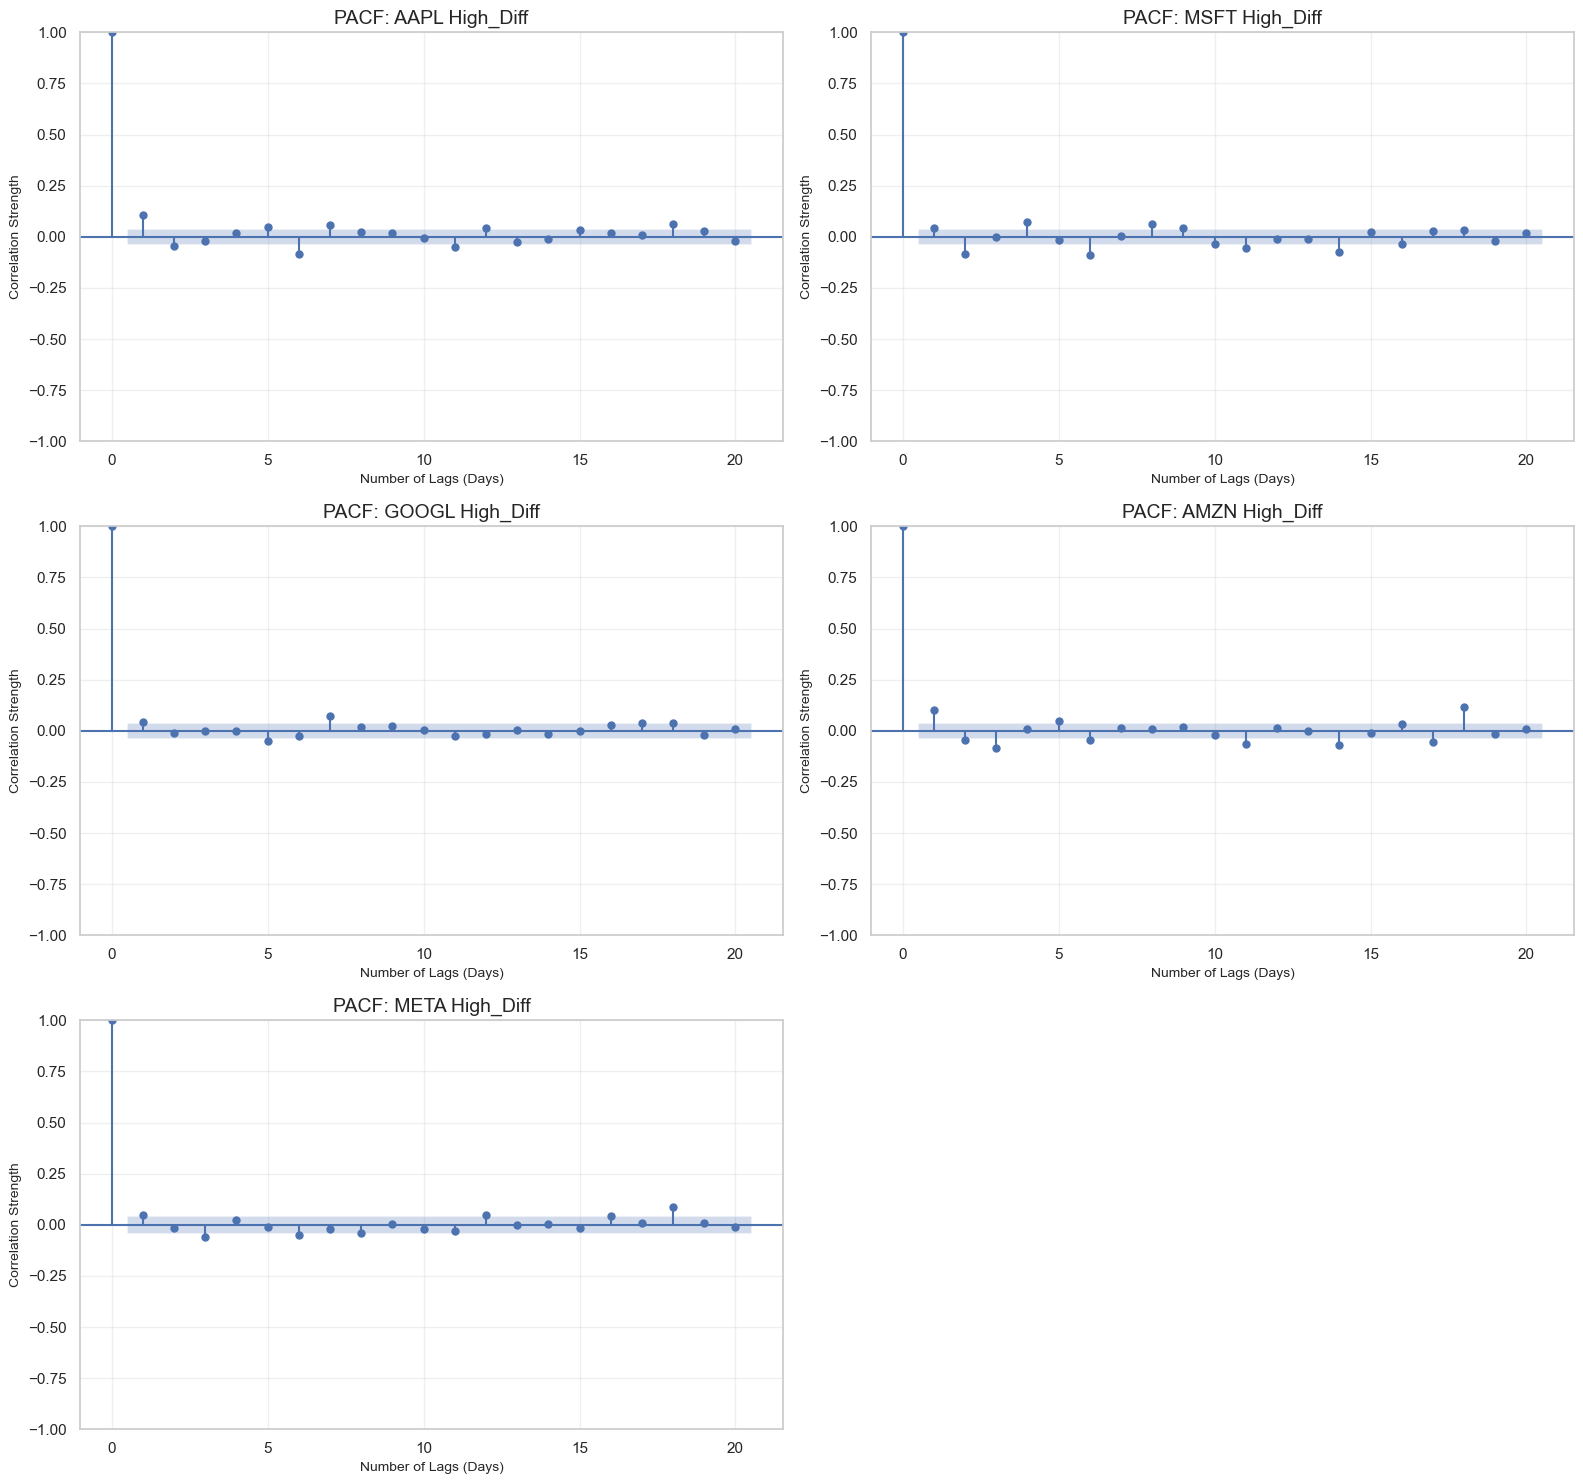

In [17]:
plot_pacf_grid(cleaned_train_dfs, tickers, lags=20)

- The PACF graphs show that the best number of lags for each stock differs, however, a good middle ground is 7 lags (one week).
- 7 days are better than 6 or 8 (which would be more suitable on some individual stocks), since it can capture weekly patterns.

# 5. Time series forecasting

Before time series forecast model, the data has to be prepared by adding these features:
- Vol_7d: The 7-day rolling standard deviation of the price change (High_Diff), measuring short-term volatility
- SMA_20: A 20-day Simple Moving Average of the Original_High
- Dist_SMA_20: A normalized value representing how far the current price is from its 20-day average
- MACD: The Moving Average Convergence Divergence, calculated as the difference between the 12-day and 26-day Exponential Moving Averages (EMA)
- RSI: The Relative Strength Index (14-day), which measures the speed and change of price movements
- Bollinger Bands (Upper_BB, Lower_BB): Standardized price envelopes
- BB_Percent: This indicates where the current price sits within the Bollinger Bands as a percentage
- Vol_Mean_20 & Vol_Std_20: The 20-day rolling mean and standard deviation of trading volume
- Vol_ZScore: Standardizes current volume relative to the past 20 days to detect "volume spikes"
- Lags (lag_1 to lag_7): Autoregressive features containing the price changes for the previous 7 trading days
- Relative_Performance: The difference between an individual stock's performance and the average performance of all tickers in the dataset for that specific day

In [ ]:
master_train_df = create_master_dataset(cleaned_train_dfs)
print(master_train_df[['Ticker', 'Vol_7d', 'RSI', 'Target', 'Relative_Performance']].head())
print(master_train_df[['Ticker', 'Vol_7d', 'RSI', 'Target']].head())

           Ticker    Vol_7d        RSI    Target  Relative_Performance
Date                                                                  
2010-02-02   AAPL  0.152741  34.925000  0.116152              0.082230
2010-02-03   AAPL  0.163224  38.664864 -0.054784             -0.019121
2010-02-04   AAPL  0.102120  37.584829 -0.070947              0.029409
2010-02-05   AAPL  0.101436  34.375093  0.056279              0.049221
2010-02-08   AAPL  0.101290  32.047432 -0.011375             -0.015125
           Ticker    Vol_7d        RSI    Target
Date                                            
2010-02-02   AAPL  0.152741  34.925000  0.116152
2010-02-03   AAPL  0.163224  38.664864 -0.054784
2010-02-04   AAPL  0.102120  37.584829 -0.070947
2010-02-05   AAPL  0.101436  34.375093  0.056279
2010-02-08   AAPL  0.101290  32.047432 -0.011375


The same feature engineering is done on the validation and testing datasets.

In [ ]:
master_val_df = create_master_dataset(cleaned_val_dfs)

           Ticker    Vol_7d        RSI    Target  Relative_Performance
Date                                                                  
2021-06-11   AAPL  1.056025  47.177498  3.021746             -0.775238
2021-06-14   AAPL  1.410670  60.030975  0.058476              1.089167
2021-06-15   AAPL  1.416072  59.019025  0.282700             -0.761340
2021-06-16   AAPL  1.409972  64.583350  1.618056              0.465815
2021-06-17   AAPL  1.339103  68.307236 -1.013768              0.149290
           Ticker    Vol_7d        RSI    Target
Date                                            
2021-06-11   AAPL  1.056025  47.177498  3.021746
2021-06-14   AAPL  1.410670  60.030975  0.058476
2021-06-15   AAPL  1.416072  59.019025  0.282700
2021-06-16   AAPL  1.409972  64.583350  1.618056
2021-06-17   AAPL  1.339103  68.307236 -1.013768


In [ ]:
master_test_df = create_master_dataset(cleaned_test_dfs)

           Ticker    Vol_7d        RSI    Target  Relative_Performance
Date                                                                  
2023-11-16   AAPL  1.023822  93.134905 -0.573490              1.639465
2023-11-17   AAPL  1.235485  90.268640  1.512859             -0.403959
2023-11-20   AAPL  1.237024  91.813640 -0.385637             -1.337574
2023-11-21   AAPL  1.142533  89.006813  1.394229              1.016298
2023-11-22   AAPL  1.021721  87.851649 -2.007276             -1.368138
           Ticker    Vol_7d        RSI    Target
Date                                            
2023-11-16   AAPL  1.023822  93.134905 -0.573490
2023-11-17   AAPL  1.235485  90.268640  1.512859
2023-11-20   AAPL  1.237024  91.813640 -0.385637
2023-11-21   AAPL  1.142533  89.006813  1.394229
2023-11-22   AAPL  1.021721  87.851649 -2.007276


Splitting datasets into features (X) and target (y).

In [21]:
X_train, y_train = prepare_feature_matrices(master_train_df)
X_val, y_val = prepare_feature_matrices(master_val_df)
X_test, y_test = prepare_feature_matrices(master_test_df)

In [22]:
numeric_features = [
    'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 
    'Vol_7d', 'Dist_SMA_20', 'RSI', 'Vol_ZScore', 'MACD', 
    'BB_Percent', 'Relative_Performance'
]
categorical_features = ['Ticker']

Preprocessing data so it is suitable for the models:
- one hot encoding categorical data (needed for gradient based models, like Ridge)
- scaling numeric data (necessary for models like Ridge)

In [23]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        
        ('num', StandardScaler(), numeric_features)
    ],
    remainder='drop' 
)

global_model = Pipeline([
    ('prep', preprocessor),
    ('regressor', Ridge(alpha=471.06, solver='cholesky', random_state=42))
])

In [24]:
models_to_test = {
    "Ridge": Ridge(alpha=1.0),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "LightGBM": LGBMRegressor(n_estimators=100, learning_rate=0.05, random_state=42, verbose=-1),
    "CatBoost": CatBoostRegressor(n_estimators=100, learning_rate=0.05, silent=True, random_state=42)
}

results = []

for name, model in models_to_test.items():
    global_model.set_params(regressor=model)
    
    global_model.fit(X_train, y_train)
    
    for ticker in tickers:
        mask = X_val['Ticker'] == ticker
        
        if mask.any():
            preds = global_model.predict(X_val[mask])
            
            actuals = y_val[mask]
            mae = np.mean(np.abs(preds - actuals))
            
            results.append({
                'Model': name,
                'Ticker': ticker,
                'MAE': mae
            })
        else:
            print(f"Warning: No data found in X_val for ticker {ticker}")

comparison_df = pd.DataFrame(results)
ranking_avg = comparison_df.groupby('Model')['MAE'].mean().sort_values()

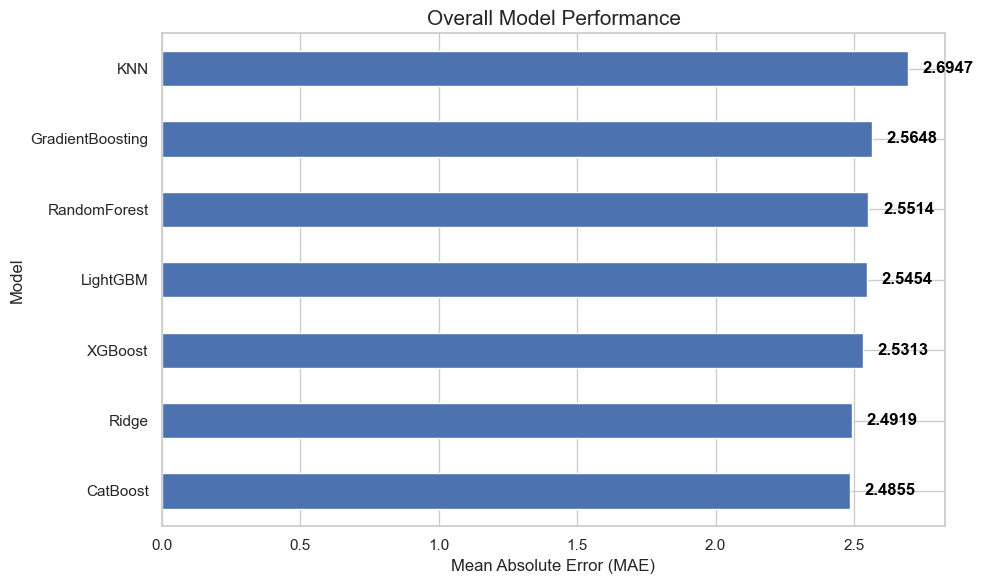

In [25]:
plot_model_comparison(ranking_avg)

- The best model (before fine tuning) is CatBoost
- Ridge regression model performed also good, which is interesting, since this model is linear. This means that the features have strong linear relationship with the target
- XGBoost, LightGBM and RandomForest performed similarly.

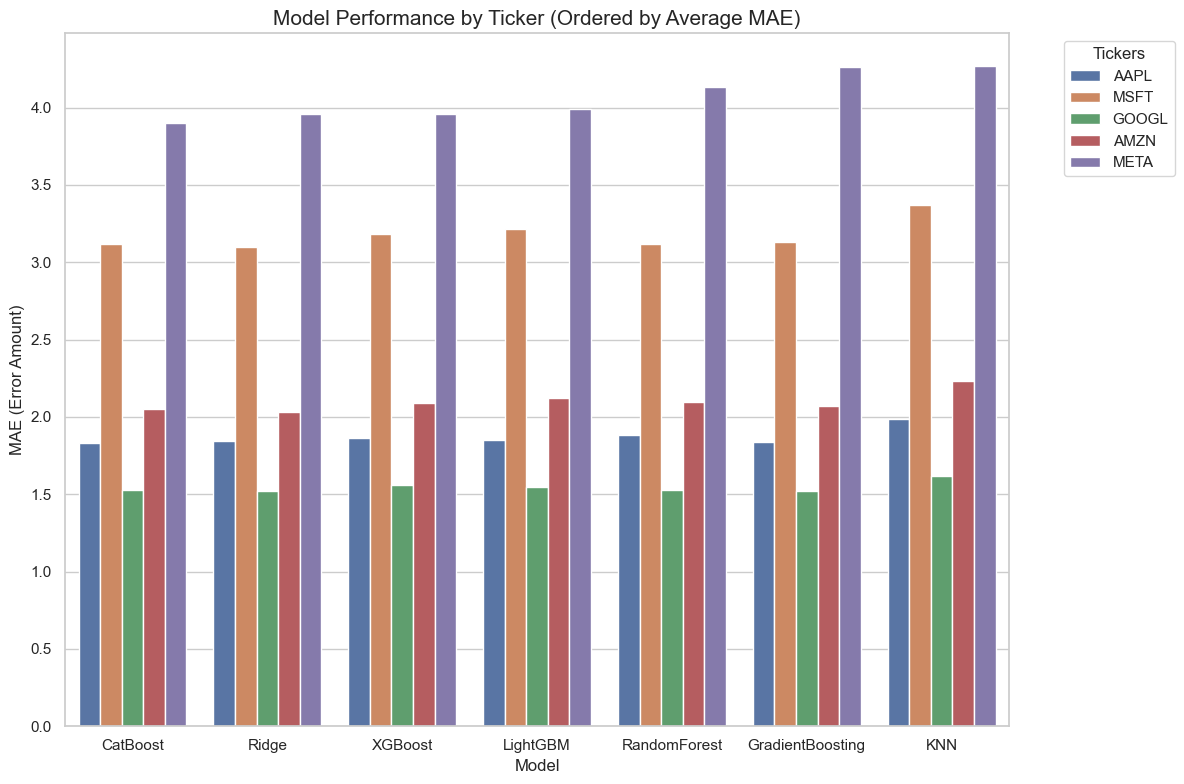

In [26]:
model_order = ranking_avg.index.tolist()
plot_ticker_performance_comparison(comparison_df, ranking_avg, model_order=model_order)

- GOOGL has the lowest MAE with all tested models, which tells that its price fluctiuations aligns with the engineered features
- META has the highest MAE, this shows intense and unpredictable price swings. It is hard to predict the price based on the engineered features

The models can be compared to the baseline model, which is just predicting yesterday's price.

In [27]:
baseline_results = {}

for ticker in tickers:
    actuals = cleaned_val_dfs[ticker]['High_Diff']
    naive_preds = actuals.shift(1)
    
    valid_indices = naive_preds.dropna().index
    y_true = actuals.loc[valid_indices]
    y_naive = naive_preds.loc[valid_indices]
    
    baseline_mae = np.mean(np.abs(y_true - y_naive))
    baseline_results[ticker] = baseline_mae

    print(f"{ticker} Baseline MAE: {baseline_mae:.4f}")

AAPL Baseline MAE: 2.4383
MSFT Baseline MAE: 4.1871
GOOGL Baseline MAE: 2.0745
AMZN Baseline MAE: 2.7213
META Baseline MAE: 5.4394


Comparing to the baseline model, all models perform better.

The best three models will be fine tuned so find the best parameters, which can be later be used to build an ensemble.

In [28]:
def objective(trial):
    regressor_name = trial.suggest_categorical(
        "model", ["Ridge", "CatBoost", "XGBoost"]
    )
    
    if regressor_name == "Ridge":
        model = Ridge(
            alpha=trial.suggest_float("ridge_alpha", 0.1, 1000.0, log=True),
            solver=trial.suggest_categorical("ridge_solver", ['auto', 'svd', 'cholesky', 'lsqr', 'sag']),
            random_state=42
        )

    elif regressor_name == "CatBoost":
        model = CatBoostRegressor(
            iterations=trial.suggest_int("cb_iterations", 100, 1000),
            learning_rate=trial.suggest_float("cb_learning_rate", 0.001, 0.1, log=True),
            depth=trial.suggest_int("cb_depth", 2, 10),
            l2_leaf_reg=trial.suggest_float("cb_l2_reg", 1.0, 20, log=True),
            subsample=trial.suggest_float("cb_subsample", 0.05, 1.0),
            random_strength=trial.suggest_float("cb_random_strength", 1e-9, 10, log=True),
            loss_function="MAE", 
            random_state=42,
            verbose=False
        )

    elif regressor_name == "XGBoost":
        model = XGBRegressor(
            n_estimators=trial.suggest_int("xgb_n_estimators", 100, 1000),
            learning_rate=trial.suggest_float("xgb_learning_rate", 0.001, 0.1, log=True),
            max_depth=trial.suggest_int("xgb_max_depth", 3, 12),
            subsample=trial.suggest_float("xgb_subsample", 0.5, 1.0),
            min_child_weight=trial.suggest_int("xgb_min_child_weight", 1, 40),
            objective='reg:absoluteerror', 
            tree_method='hist',
            random_state=42,
            n_jobs=-1
        )

    pipeline = Pipeline([('prep', preprocessor), ('reg', model)])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_val)

    mae = mean_absolute_error(y_val, y_pred)
    
    return mae

In [ ]:
# study = optuna.create_study(direction="minimize")
# study.optimize(objective, n_trials=50)
# joblib.dump(study, "optuna_stock_study.pkl")

['optuna_stock_study.pkl']

In [ ]:
study = joblib.load("optuna_stock_study.pkl")

In [30]:
ridge_best = get_best_params_for_model(study, "Ridge")
cat_best = get_best_params_for_model(study, "CatBoost")
xgb_best = get_best_params_for_model(study, "XGBoost")

In [31]:
model1 = Ridge(
    **clean_params(ridge_best['params'], 'ridge_'), 
    random_state=42
)

cleaned_cb_params = clean_params(cat_best['params'], 'cb_')
if 'l2_reg' in cleaned_cb_params:
    cleaned_cb_params['l2_leaf_reg'] = cleaned_cb_params.pop('l2_reg')

model2 = CatBoostRegressor(
    **cleaned_cb_params,
    loss_function='MAE', 
    verbose=False,
    random_state=42
)

model3 = XGBRegressor(
    **clean_params(xgb_best['params'], 'xgb_'),
    objective='reg:absoluteerror',
    tree_method='hist',
    random_state=42
)

First, let's try to build an ensemble of all three models.

In [32]:
ensemble = VotingRegressor(estimators=[
    ('ridge', model1),
    ('cat', model2),
    ('xgb', model3)
])

pipeline_ensemble_3 = Pipeline([('prep', preprocessor), ('reg', ensemble)])

pipeline_ensemble_3.fit(X_train, y_train)
y_pred_ensemble_3 = pipeline_ensemble_3.predict(X_val)

Ensemble Voting Regressor MAE: 2.471063


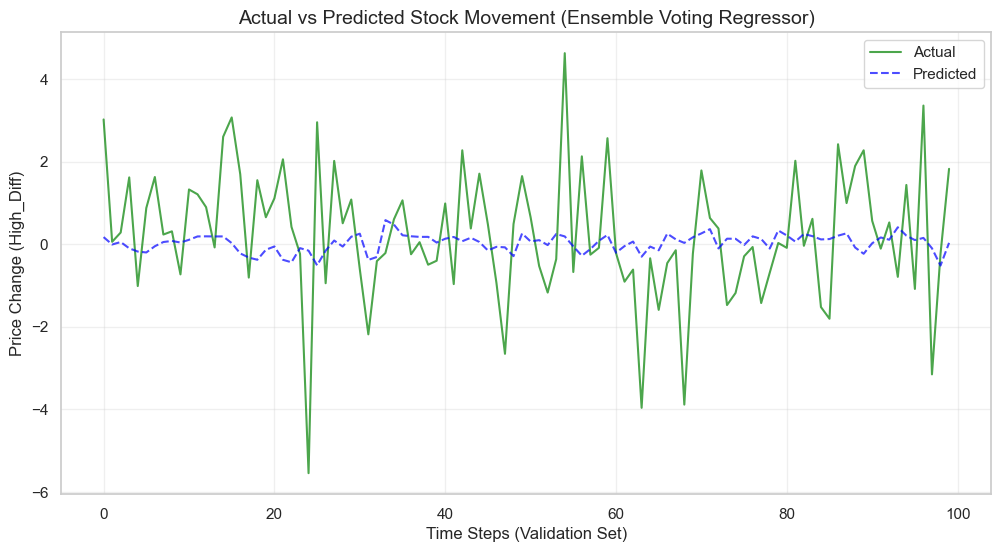

In [33]:
evaluate_ensemble(y_val, y_pred_ensemble_3)

- The ensemble model of all three models tries to predict the price change direction, but it struggles to predict intense highs or lows.
- MAE = 2.471

Now let's exclude the linear model Ridge from the ensemble, which can make the predictions worse, since it's a linear model.

In [34]:
ensemble = VotingRegressor(estimators=[
    ('cat', model2),
    ('xgb', model3)
])

pipeline_ensemble_2 = Pipeline([('prep', preprocessor), ('reg', ensemble)])

pipeline_ensemble_2.fit(X_train, y_train)
y_pred_ensemble_2 = pipeline_ensemble_2.predict(X_val)

Ensemble Voting Regressor MAE: 2.467054


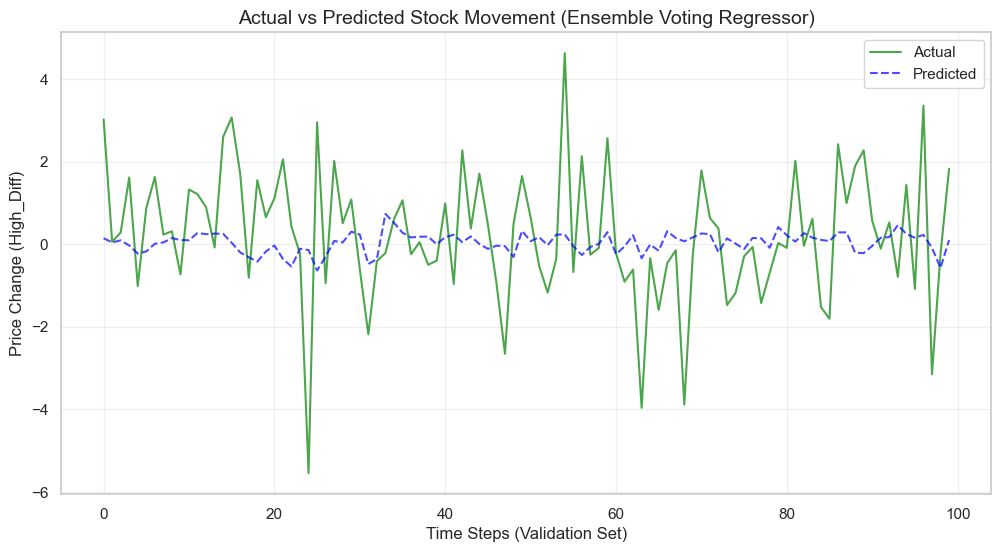

In [35]:
evaluate_ensemble(y_val, y_pred_ensemble_2)

- The predictions looks similar to the previous ensemble
- MAE is slightly better (2.467 comparing to 2.471)

Let's add back the Ridge, but make it the estimator on when to use the other two models, using stacking ensemble.

In [36]:
stack_ensemble = StackingRegressor(
    estimators=[('cat', model2), ('xgb', model3)],
    final_estimator=Ridge()
)

pipeline_stack_ensemble = Pipeline([('prep', preprocessor), ('reg', stack_ensemble)])

pipeline_stack_ensemble.fit(X_train, y_train)
y_pred_stack_ensemble = pipeline_stack_ensemble.predict(X_val)

Ensemble Voting Regressor MAE: 2.477840


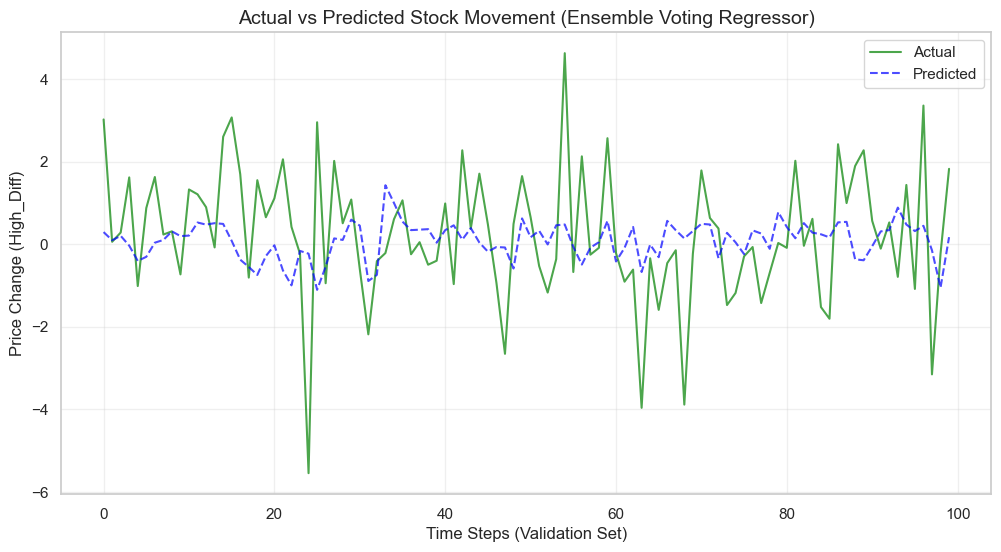

In [37]:
evaluate_ensemble(y_val, y_pred_stack_ensemble)

- Now the ensemble has a bit easier time predicting the intense highs and lows.
- The MAE is similar (2.478) but slightly lower than the previous ensembles.
- This ensemble will be chosen as the final model for forecasting.

Testing the final model on the test data.

In [ ]:
y_pred_stack_ensemble = pipeline_stack_ensemble.predict(X_test)
evaluate_ensemble(y_test, y_pred_stack_ensemble)

# 6. Survival analysis

To prepare data for survival analysis, the following features must be added:
- SMA_20: A 20-day Simple Moving Average providing a baseline price level.
- Dist_SMA_20: Measures how far the current price has deviated from its 20-day mean
- MACD: Captures trend strength by calculating the difference between 12-day and 26-day Exponential Moving Averages.
- Vol_7d: The 7-day rolling standard deviation of daily price changes.
- Bollinger Bands (Upper_BB, Lower_BB, BB_Percent): These define a price envelope around the SMA_20 using Vol_7d. %B specifically indicates where the price sits relative to these bands.
- RSI: A 14-day Relative Strength Index to identify overbought or oversold conditions.
- Vol_ZScore: Standardizes trading volume relative to its 20-day mean and standard deviation to highlight unusual market interest.
- lag_1 to lag_7: Provides the model with the last 7 days of price changes (High_Diff), capturing short-term weekly cycles.
- Daily_Pct_Return: Calculated as the current daily price change relative to the previous day's close.
- Duration: This represents the "time" component. For each day, the code looks forward to see how many days it takes for the return to hit > 5% .
- Event: This is the censoring indicator. It is set to 1 if the 5% threshold was successfully met ("the event occurred") and 0 if the data ended before the threshold was reached ("censored").
- Relative_Performance: Adds market context by subtracting the average daily price change of all tickers from each individual stock's performance.

In [38]:
all_survival_data = []
threshold = 0.05


for ticker, df in cleaned_train_dfs.items():
    df = df.copy()
    df['Ticker'] = ticker

    df['Vol_7d'] = df['High_Diff'].rolling(window=7).std()
    df['SMA_20'] = df['Original_High'].rolling(window=20).mean()
    df['Dist_SMA_20'] = (df['Original_High'] / df['SMA_20']) - 1

    delta = df['High_Diff']
    up = delta.clip(lower=0).rolling(window=14).mean()
    down = -delta.clip(upper=0).rolling(window=14).mean()
    rs = up / down.replace(0, np.nan)
    df['RSI'] = 100 - (100 / (1 + rs))
    df['RSI'] = df['RSI'].fillna(50)
    df['Vol_Mean_20'] = df['Volume'].rolling(window=20).mean()
    df['Vol_Std_20'] = df['Volume'].rolling(window=20).std()
    df['Vol_ZScore'] = (df['Volume'] - df['Vol_Mean_20']) / (df['Vol_Std_20'] + 1e-9)

    ema_12 = df['Original_High'].ewm(span=12, adjust=False).mean()
    ema_26 = df['Original_High'].ewm(span=26, adjust=False).mean()
    df['MACD'] = ema_12 - ema_26

    df['Upper_BB'] = df['SMA_20'] + (2 * df['Vol_7d'])
    df['Lower_BB'] = df['SMA_20'] - (2 * df['Vol_7d'])
    df['BB_Percent'] = (df['Original_High'] - df['Lower_BB']) / (df['Upper_BB'] - df['Lower_BB'] + 1e-9)

    for lag in range(1, 8):
        df[f'lag_{lag}'] = df['High_Diff'].shift(lag)

    prev_close = df['Original_High'] - df['High_Diff']
    df['Daily_Pct_Return'] = df['High_Diff'] / prev_close

    returns = df['Daily_Pct_Return'].values

    n = len(returns)
    durations = np.zeros(n)
    events = np.zeros(n)

    for i in range(n):
        future_returns = returns[i+1:]
        hits = np.where(future_returns >= threshold)[0]

        if len(hits) > 0:
            durations[i] = hits[0] + 1
            events[i] = 1
        else:
            durations[i] = len(future_returns)
            events[i] = 0

    df['Duration'] = durations
    df['Event'] = events

    all_survival_data.append(df)

master_surv_df = pd.concat(all_survival_data)
master_surv_df.dropna(inplace=True)
master_surv_df = master_surv_df[master_surv_df['Duration'] > 0]

daily_market_avg = master_surv_df.groupby(level=0)['High_Diff'].transform('mean')
master_surv_df['Relative_Performance'] = master_surv_df['High_Diff'] - daily_market_avg

master_surv_df = master_surv_df.reset_index()

print(f"Survival Master DF Shape: {master_surv_df.shape}")
print(master_surv_df[['Ticker', 'Duration', 'Event']].head()) 

Survival Master DF Shape: (13591, 27)
  Ticker  Duration  Event
0   AAPL     499.0    1.0
1   AAPL     498.0    1.0
2   AAPL     497.0    1.0
3   AAPL     496.0    1.0
4   AAPL     495.0    1.0


Dividing the data into features (X) and a target (y). For the survival analysis the target y has to contain both the even and the duration until the event.

In [39]:
all_features = ['Ticker', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 
                'Vol_7d', 'Dist_SMA_20', 'RSI', 'Vol_ZScore', 'MACD', 'BB_Percent', 'Relative_Performance']

X_surv = master_surv_df[all_features]
y_surv = master_surv_df[['Event', 'Duration']]

In [40]:
y_survival = np.array(
    list(zip(master_surv_df['Event'].astype(bool), master_surv_df['Duration'])),
    dtype=[('Status', '?'), ('Time', '<f8')]
)

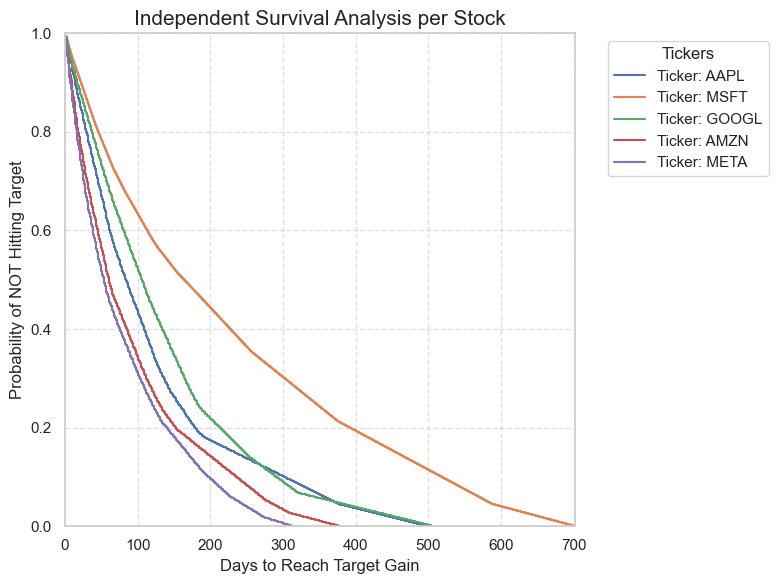

In [42]:
plot_ticker_survival_comparison(master_surv_df)

Looking at the survival curves:
- META and AMZN curves drop the fastest. For example at day 100, they have 30-40% probability that the stock hasn't hit the 5% target. These both stocks were more volatile, so it makes sense, that the price can change more intensly
- MSFT has the highest survival of all five stocks, which shows that this stocks has the fewest explosive 5% jumps in price
- GOOGL and AAPL have similar survival
- All stocks eventually reach a 5% or more increase in price (if given enough time)

Now we can model RandomSurvivalForest model to predict time to 5% gain.

In [43]:
y_surv = np.array(
    list(zip(master_surv_df['Event'].astype(bool), master_surv_df['Duration'])),
    dtype=[('Status', '?'), ('Time', '<f8')]
)

X_surv = pd.get_dummies(master_surv_df[all_features], columns=['Ticker'])

In [44]:
rsf = RandomSurvivalForest(
    n_estimators=100,
    min_samples_split=10,
    min_samples_leaf=15,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

rsf.fit(X_surv, y_surv)

,n_estimators,100
,max_depth,None
,min_samples_split,10
,min_samples_leaf,15
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,bootstrap,True
,oob_score,False
,n_jobs,-1
,random_state,42


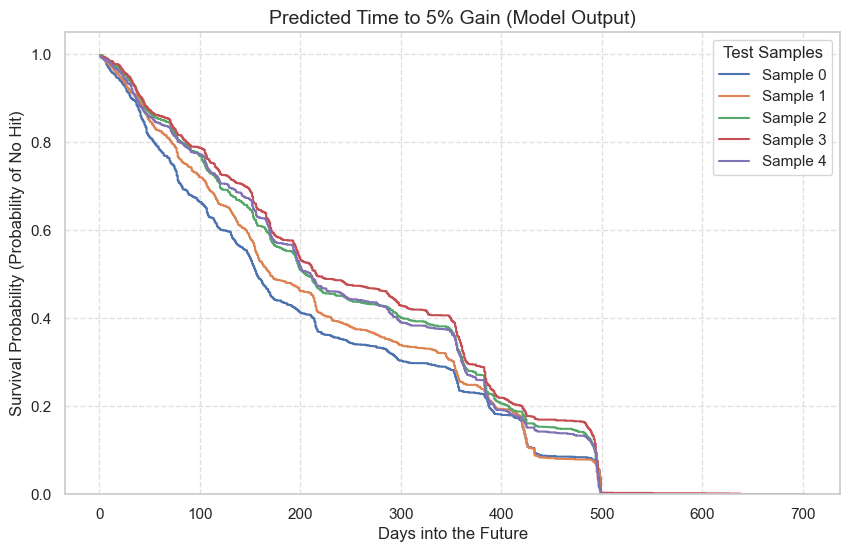

In [45]:
X_test_samples = X_surv.iloc[:5]
plot_rsf_predictions(rsf, X_test_samples)

In [46]:
prediction = rsf.predict(X_surv)
result = concordance_index_censored(y_surv["Status"], y_surv["Time"], prediction)

print(f"C-index of the Global Model: {result[0]:.4f}")

C-index of the Global Model: 0.7075


- C-index of the model is 0.7075 which shows that the model can predict the time to 5% raise right about 71% of the time
- There is a rapid fall of all curves at day 500, which shows that the model learned that if the 5% gain hasn't happened yet, it will surely happen around day 500 for all stocks.

# 7. Ranking model

To prepare data for the ranking model, the following features are needed:
- Cross-Sectional Normalization: By subtracting the daily mean of features like RSI, Vol_ZScore, Dist_SMA_20, and MACD
- Market Context Integration (Market_Return and Market_Vol)

In [ ]:
master_train_df = master_train_df.reset_index()
master_train_df = prep_ranking_data(master_train_df)

market_context = master_train_df.groupby('Date')['High_Diff'].agg(['mean', 'std']).rename(
    columns={'mean': 'Market_Return', 'std': 'Market_Vol'}
)

master_train_df = master_train_df.merge(market_context, on='Date', how='left')

features = [col for col in master_train_df.columns if 'lag' in col or '_rel' in col] 
features += ['Vol_7d', 'Market_Return', 'Market_Vol']

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,100
,subsample_for_bin,200000
,objective,'lambdarank'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


- The target is now the relevance score

In [ ]:
X = master_train_df[features]
y = master_train_df['relevance']

- The model is evaluated based on the Normalized Discounted Cumulative Gain, this measures how well the model puts the best performing stocks at the top of the list
- Grouping is needed to compare the stocks on a same specific day

In [ ]:
groups = master_train_df.groupby('Date').size().to_list()

ranker = lgb.LGBMRanker(
    objective="lambdarank",
    metric="ndcg",
    importance_type="gain",
    learning_rate=0.05,
    n_estimators=100,
    label_gain=[0, 1, 3, 7, 15]
)

ranker.fit(
    X, y, 
    group=groups,
    eval_at=[1, 3]
)

The same data engineering is done on the validation dataset.

In [48]:
market_context = master_val_df.groupby('Date')['High_Diff'].agg(['mean', 'std']).rename(
    columns={'mean': 'Market_Return', 'std': 'Market_Vol'}
)
master_val_df = master_val_df.merge(market_context, on='Date', how='left')

master_val_df = master_val_df.reset_index()
master_val_df = prep_ranking_data(master_val_df)

master_val_df['pred_score'] = ranker.predict(master_val_df[features])
acc = master_val_df.groupby('Date').apply(pairwise_accuracy).mean()
print(f"Average Pairwise Accuracy: {acc:.2%}")

Average Pairwise Accuracy: 67.92%


- The LGBMRanker ranks the stocks correctly 67.92% of the time
- The similar result (67.2%) is seen on the test data

In [49]:
market_context_test = master_test_df.groupby('Date')['High_Diff'].agg(['mean', 'std']).rename(
    columns={'mean': 'Market_Return', 'std': 'Market_Vol'}
)
master_test_df = master_test_df.merge(market_context_test, on='Date', how='left')

master_test_df = master_test_df.reset_index()
master_test_df = prep_ranking_data(master_test_df)

X_test_processed = master_test_df[features] 

master_test_df['pred_score'] = ranker.predict(X_test_processed)

acc = master_test_df.groupby('Date').apply(pairwise_accuracy).mean()
print(f"Average Pairwise Accuracy: {acc:.2%}")

Average Pairwise Accuracy: 67.20%


# Conclusions